Парная линейная регрессия
Цель работы
    Познакомиться с моделью парной линейной регрессии регрессии и методом градиентного спуска.

Содержание работы
Найти оценки параметров модели парной линейной регрессии прямыми вычислениями и палучить с помощью модели прогнозы результативного прознака.
Найти оценки параметров модели парной линейной регрессии с использованием метода градиентного спуска.
Оценить качество построенной модели, сравнив на графике обучающую выборку и прогнозы.
Построить кривые обучения.

In [1]:
#Загрузим необходимые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Исходные данные: x - расходы на рекламу, Y - объемы продаж
x = np.array([3, 5, 7, 6, 9])
Y = np.array([3, 7, 11, 14, 15])
display(x, Y)

array([3, 5, 7, 6, 9])

array([ 3,  7, 11, 14, 15])

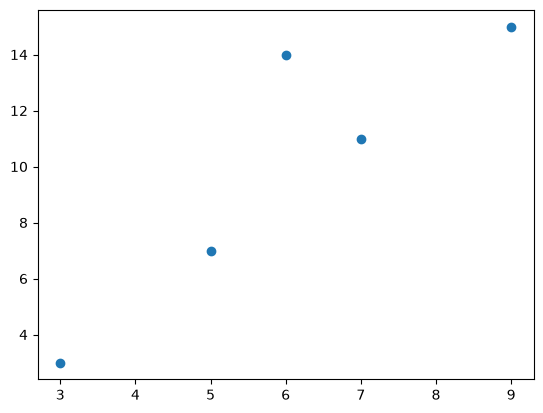

In [3]:
#Изобразим их на графике
plt.figure()
plt.scatter(x, Y)
plt.show()

In [4]:
#Вычислим оценки коэффициентов парной линейной регрессии по формулам
a1 = ((x - x.mean())*(Y - Y.mean())).mean()/((x - x.mean())**2).mean()
a0 = Y.mean() - a1*x.mean()
print("Модель линейной регрессии: Y^ = ", a0, " + ", a1, "* x")

Модель линейной регрессии: Y^ =  -2.0  +  2.0 * x


In [5]:
#Дадим серию прогнозов Y^ для x от 3 до 9 с шагом 1
x_space = np.linspace(3, 9, 7)
print(x_space)
Y_pred = a0 + a1*x_space
print(Y_pred)

[3. 4. 5. 6. 7. 8. 9.]
[ 4.  6.  8. 10. 12. 14. 16.]


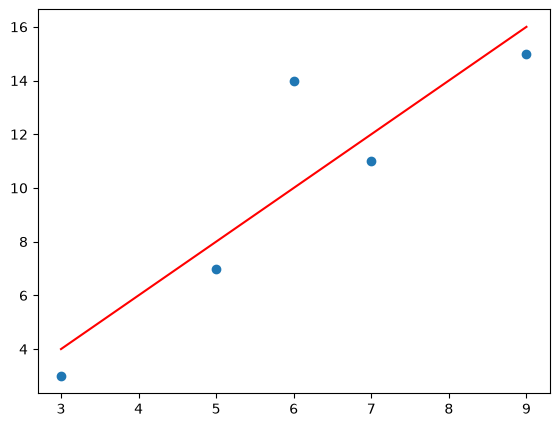

In [6]:
#Изобразим на графике исходные данные и прогнозы 
fig  = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')
#ax.scatter(x_space, Y_pred)

In [7]:
#Реализуем шаг градиентного спуска в модели парной лдинейной регрессии
class SimpleRegression(object):
    def __init__(self):
        self.a0 = 0
        self.a1 = 0
    def predict(self, x):
        return self.a0 + self.a1*x
    def MSE(self, x, Y):
        return ((self.predict(x)-Y)**2).mean()
    def fit(self, x, Y):
        alpha = 0.1
        dT_a0 = -2*sum((Y -self.predict(x)))
        dT_a1 = -2*sum((Y -self.predict(x))*x)
        self.a0 -= alpha*dT_a0
        self.a1 -= alpha*dT_a1

In [8]:
#Получим прогнозы до градиентного спуска с начальными значениями параметров
regr = SimpleRegression()
print(regr.predict(3))
print(regr.predict(5))
print(regr.predict(7))
print(regr.predict(6))
print(regr.predict(9))
print(regr.MSE(x, Y))

0
0
0
0
0
120.0


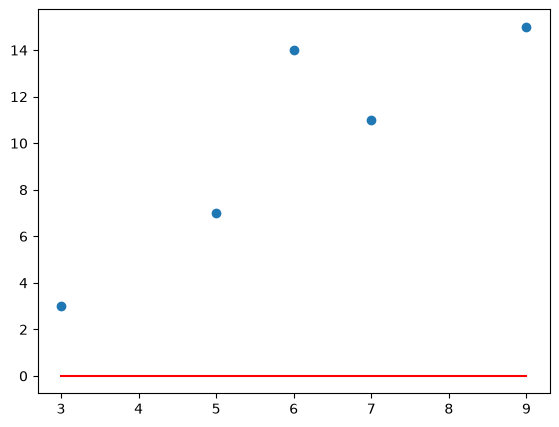

In [9]:
#Выведем прогнозы до градиентного спуска на графике
x_space = np.linspace(3, 9, 7)
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')

MSE после первого шага градиентного спуска:  183892.0


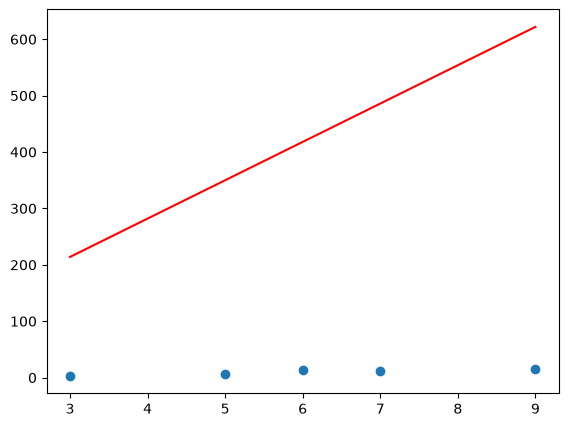

In [10]:
#Реализуем шаг градиентного спуска
regr.fit(x, Y)
print("MSE после первого шага градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')

In [11]:
#Реализуем цикл градиентного спуска
class SimpleRegression(object):
    def __init__(self):
        self.a0 = 0
        self.a1 = 0
    def predict(self, x):
        return self.a0 + self.a1*x
    def MSE(self, x, Y):
        return ((Y - self.predict(x))**2).mean()
    def MAE(self, x, Y):
        return abs(Y - self.predict(x)).mean()
    def MAPE(self, x, Y):
        return abs((Y - self.predict(x))/Y).mean()
    def fit(self, x, Y, alpha = 0.001, epsylon = 0.01, max_steps = 5000):
        steps, errors = [], []
        step = 0
        for _ in range(max_steps):
            dT_a0 = -2*sum((Y -self.predict(x)))
            dT_a1 = -2*sum((Y -self.predict(x))*x)
            self.a0 -= alpha*dT_a0
            self.a1 -= alpha*dT_a1
            new_error = self.MSE(x, Y)
            step += 1
            steps.append(step)
            errors.append(new_error)
            if new_error < epsylon:
                break
        return steps, errors

In [12]:
#Запустим цикл градиентного спуска с заданной точностью 5
regr = SimpleRegression()
steps, errors = regr.fit(x, Y, alpha = 0.001, epsylon = 5)

5.004697916218
8.190462542210001
11.376227168202002
9.783344855206002
14.561991794194002
MSE после градиентного спуска:  4.709918696051655


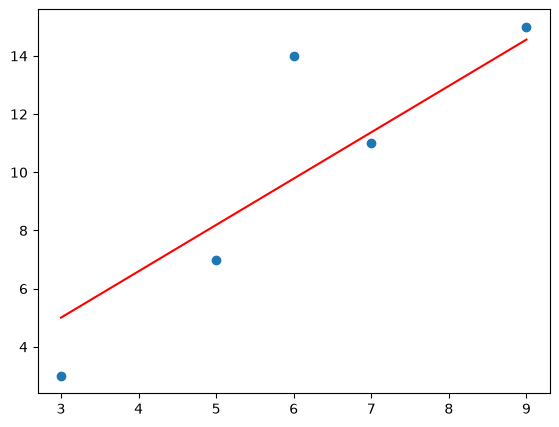

In [13]:
#Выведем график  прогнозов и вычислим MSE
print(regr.predict(3))
print(regr.predict(5))
print(regr.predict(7))
print(regr.predict(6))
print(regr.predict(9))
print("MSE после градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')

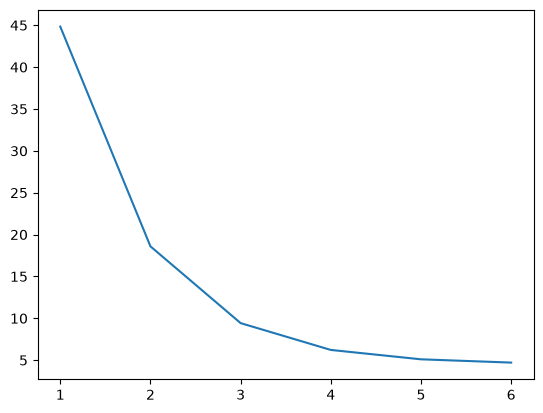

In [14]:
#Выведем график изменения MSE в процессе градиентного спуска
plt.figure()
plt.plot(steps, errors)

In [15]:
#Запустим цикл градиентного спуска с заданной точностью 0.05
regr = SimpleRegression()
steps, errors = regr.fit(x, Y, alpha = 0.001, epsylon = 0.05)

MSE после градиентного спуска:  4.000028517306817


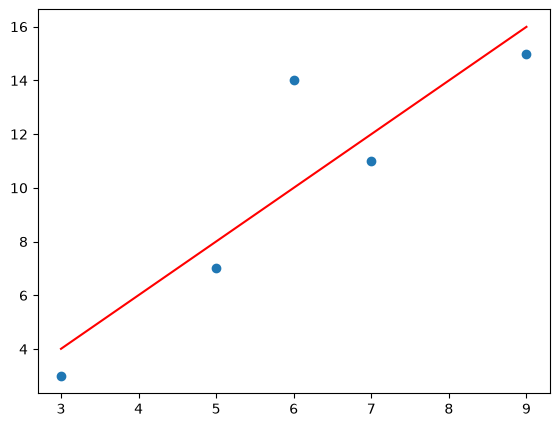

In [16]:
#Выведем график прогнозов и вычислим MSE
print("MSE после градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')

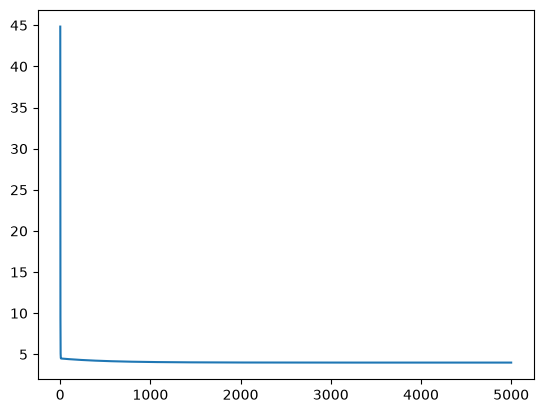

In [17]:
#Выведем график изменения MSE в процессе градиентного спуска
plt.figure()
plt.plot(steps, errors)

MSE после градиентного спуска:  4.1903709155046345


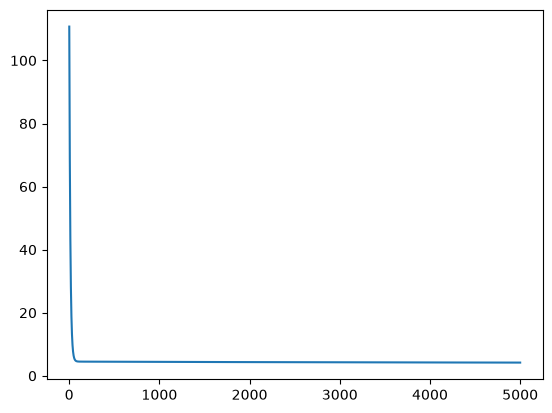

In [18]:
#Запустим цикл градиентного спуска с разными значениями скорости обучения alpha=0.0001, 0.01, 0.1, 1, 10, ..., 
#с различной допукстимой точностью epsylon = 0.001, 0.5, 5, с различным максимальным количеством шагов max_steps
regr = SimpleRegression()
steps, errors = regr.fit(x, Y, alpha = 0.0001, epsylon = 0.01, max_steps = 5000)
print("MSE после градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
plt.figure()
plt.plot(steps, errors)

Загрузите файл Гиперспектр кукурузы.csv (с помощью pd.read_csv).

1. Вычислите аналитическим путем оценки коэффициентов парной линейной регрессии и постройте ее график.
2. Найдите оценки параметров модели парной лиенйной регрессии с использованием метода градиентного спуска. Постройте график.
3. Оцените качество построенных моделей сравнив на графике обучающую выборку и прогнозы.


In [19]:
gipers = pd.read_csv(r"Гиперспектр кукурузы.csv", sep=';', decimal=',', encoding='utf-8-sig')
gipers.head()

,wavelength,Spectr
0,397.32,0.02
1,399.54,0.03
2,401.76,0.03
3,403.98,0.05
4,406.20,0.05


### 1. Аналитическая оценка параметров парной линейной регрессии

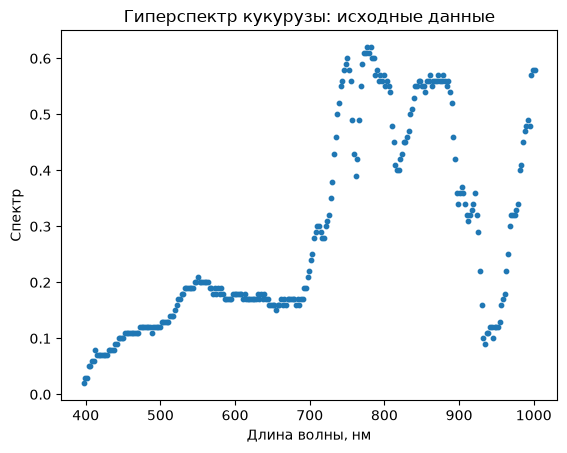

In [20]:
#Выделим признак (длина волны) и целевую переменную (спектр)
x = gipers['wavelength'].values
Y = gipers['Spectr'].values

plt.figure()
plt.scatter(x, Y, s=10)
plt.xlabel('Длина волны, нм')
plt.ylabel('Спектр')
plt.title('Гиперспектр кукурузы: исходные данные')
plt.show()

Модель линейной регрессии (аналитически): Y^ = -0.183428 + 0.000668 * x


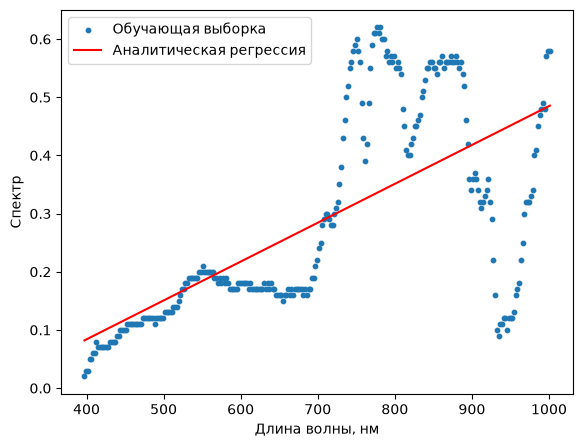

In [21]:
#Вычислим оценки коэффициентов парной линейной регрессии по формулам
a1 = ((x - x.mean())*(Y - Y.mean())).mean()/((x - x.mean())**2).mean()
a0 = Y.mean() - a1*x.mean()
print("Модель линейной регрессии (аналитически): Y^ = {:.6f} + {:.6f} * x".format(a0, a1))

x_space = np.linspace(x.min(), x.max(), 200)
Y_pred_analytic = a0 + a1*x_space

fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y, s=10, label='Обучающая выборка')
ax.plot(x_space, Y_pred_analytic, 'r', label='Аналитическая регрессия')
ax.set_xlabel('Длина волны, нм')
ax.set_ylabel('Спектр')
ax.legend()
plt.show()

### 2. Оценка параметров методом градиентного спуска

Признак `wavelength` принимает значения порядка нескольких сотен нм, тогда как в исходном учебном примере x был порядка единиц. При таком масштабе градиент по `a1` на много порядков больше градиента по `a0`, поэтому цикл градиентного спуска из класса `SimpleRegression` с разумным значением `alpha` расходится (или сходится крайне медленно).

Чтобы метод сходился устойчиво и быстро, стандартизируем признак x перед обучением: $x_{std} = (x - \bar{x}) / \sigma_x$, обучим модель на $x_{std}$, а затем пересчитаем коэффициенты обратно в исходный масштаб x.

In [22]:
#Стандартизируем признак и обучим модель градиентным спуском
x_mean, x_std = x.mean(), x.std()
x_scaled = (x - x_mean) / x_std

regr_gd = SimpleRegression()
steps, errors = regr_gd.fit(x_scaled, Y, alpha=0.0001, epsylon=0.001, max_steps=5000)

#Пересчитываем коэффициенты обратно в масштаб исходного признака x
a1_gd = regr_gd.a1 / x_std
a0_gd = regr_gd.a0 - regr_gd.a1 * x_mean / x_std
print("Модель линейной регрессии (градиентный спуск): Y^ = {:.6f} + {:.6f} * x".format(a0_gd, a1_gd))
print("Число шагов:", len(steps), " MSE:", errors[-1])

Модель линейной регрессии (градиентный спуск): Y^ = -0.183428 + 0.000668 * x


Число шагов: 5000  MSE: 0.0176841146283014


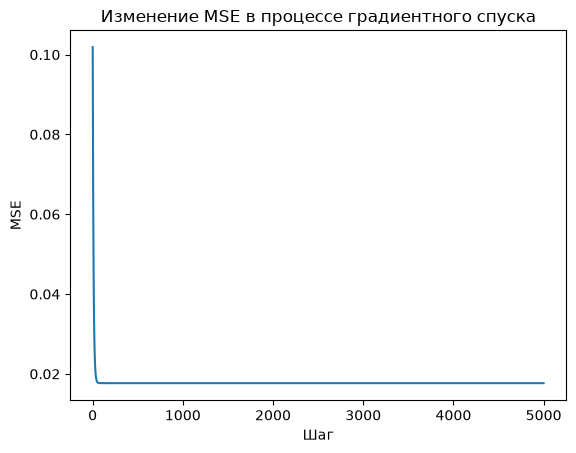

In [23]:
#Выведем график изменения MSE в процессе градиентного спуска
plt.figure()
plt.plot(steps, errors)
plt.xlabel('Шаг')
plt.ylabel('MSE')
plt.title('Изменение MSE в процессе градиентного спуска')
plt.show()

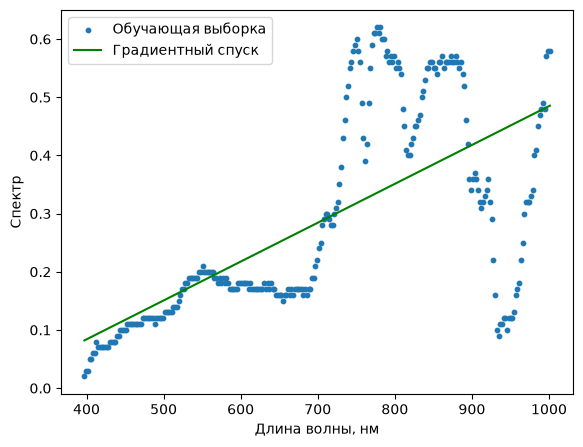

In [24]:
#Выведем график прогнозов модели, полученной градиентным спуском
Y_pred_gd = a0_gd + a1_gd*x_space

fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y, s=10, label='Обучающая выборка')
ax.plot(x_space, Y_pred_gd, 'g', label='Градиентный спуск')
ax.set_xlabel('Длина волны, нм')
ax.set_ylabel('Спектр')
ax.legend()
plt.show()

### 3. Сравнение качества моделей

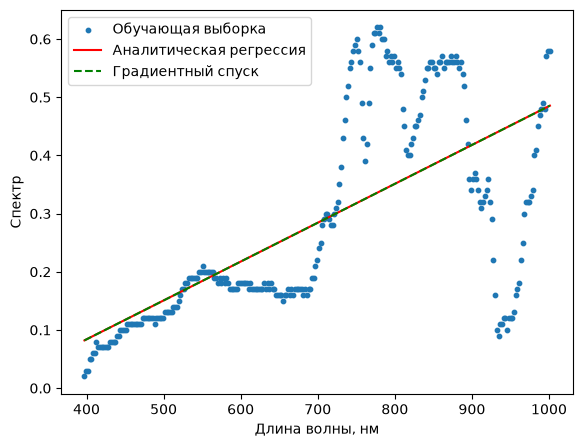

MSE аналитической модели: 0.017684
MSE модели градиентного спуска: 0.017684
Дисперсия Y (базовый уровень MSE константной модели): 0.031349


In [25]:
#Сравним на одном графике обучающую выборку и прогнозы обеих моделей
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y, s=10, label='Обучающая выборка')
ax.plot(x_space, Y_pred_analytic, 'r', label='Аналитическая регрессия')
ax.plot(x_space, Y_pred_gd, 'g--', label='Градиентный спуск')
ax.set_xlabel('Длина волны, нм')
ax.set_ylabel('Спектр')
ax.legend()
plt.show()

mse_analytic = ((Y - (a0 + a1*x))**2).mean()
mse_gd = ((Y - (a0_gd + a1_gd*x))**2).mean()
print("MSE аналитической модели: {:.6f}".format(mse_analytic))
print("MSE модели градиентного спуска: {:.6f}".format(mse_gd))
print("Дисперсия Y (базовый уровень MSE константной модели): {:.6f}".format(Y.var()))

### Кривые обучения при разных скоростях обучения alpha
Запустим градиентный спуск на стандартизированном признаке с разными `alpha` и сравним изменение MSE по шагам. Для `alpha = 0.01` метод расходится, поэтому его результат выведем текстом.

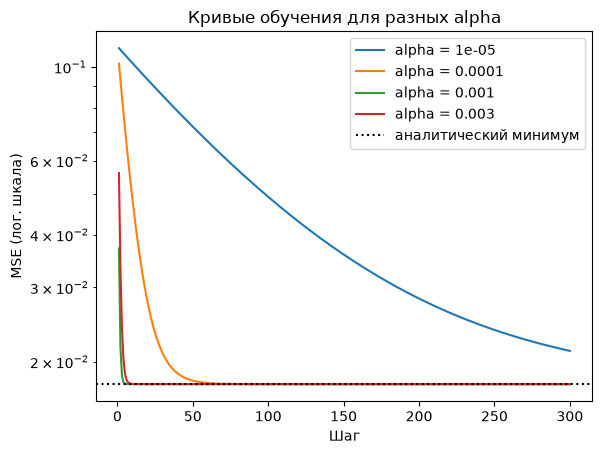

alpha = 0.01: MSE после 50 шагов = 8.081622317516225e+63 — метод расходится


In [26]:
plt.figure()
for alpha in [0.00001, 0.0001, 0.001, 0.003]:
    r = SimpleRegression()
    st, er = r.fit(x_scaled, Y, alpha=alpha, epsylon=1e-9, max_steps=300)
    plt.plot(st, er, label='alpha = {}'.format(alpha))
plt.axhline(mse_analytic, color='k', ls=':', label='аналитический минимум')
plt.yscale('log')
plt.xlabel('Шаг')
plt.ylabel('MSE (лог. шкала)')
plt.title('Кривые обучения для разных alpha')
plt.legend()
plt.show()

with np.errstate(all='ignore'):
    r = SimpleRegression()
    st, er = r.fit(x_scaled, Y, alpha=0.01, epsylon=1e-9, max_steps=50)
print("alpha = 0.01: MSE после 50 шагов =", er[-1], "— метод расходится")

Слишком малое `alpha` (1e-5) сходится медленно, при `alpha` 1e-3 … 3e-3 метод достигает минимума за несколько десятков шагов, а при `alpha = 0.01` шаг слишком велик и ошибка растёт.

In [27]:
#Дополнительные метрики качества обеих моделей: MAE и MAPE
def metrics(a0_, a1_):
    m = SimpleRegression()
    m.a0, m.a1 = a0_, a1_
    return m.MSE(x, Y), m.MAE(x, Y), m.MAPE(x, Y)

pd.DataFrame({'Аналитически': metrics(a0, a1), 'Градиентный спуск': metrics(a0_gd, a1_gd)},
             index=['MSE', 'MAE', 'MAPE']).round(6)

,Аналитически,Градиентный спуск
MSE,0.017684,0.017684
MAE,0.096834,0.096834
MAPE,0.433770,0.433770


**Вывод.** Коэффициенты, полученные аналитически и методом градиентного спуска (после стандартизации признака), практически совпадают, а значит обе модели дают одинаковое качество прогноза (MSE $\approx$ 0.0177). Линия регрессии верно улавливает общую тенденцию роста спектра с увеличением длины волны, однако линейная модель объясняет лишь около 44% дисперсии Y (MSE 0.0177 против дисперсии Y $\approx$ 0.0315) — по графику видно, что реальная зависимость нелинейна, и для более точного описания данных потребовалась бы полиномиальная регрессия.

По кривым обучения видно, что при подходящем `alpha` градиентный спуск за несколько десятков шагов выходит на аналитический минимум MSE, а слишком большое `alpha` приводит к расходимости.